In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle
import warnings
from collections import deque

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, 
    f1_score, roc_auc_score, roc_curve, auc
)
from sklearn.model_selection import cross_val_score, StratifiedKFold

from utils.calculador_angulos import calculate_angle, extract_angles_from_landmarks

warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Bibliotecas importadas com sucesso")

✓ Bibliotecas importadas com sucesso


## 1. Import Required Libraries

# Random Forest Classification with Temporal Features
## Exercise Classification Using 10-Frame Windows

This notebook implements a Random Forest classifier with proper temporal feature engineering for exercise classification (flexão vs descanso). Special care is taken to respect the temporal nature of the data and avoid data leakage.

### Key Concepts:
- **Temporal Windowing**: Uses sliding windows of 10 frames for classification
- **Feature Engineering**: Includes statistical, velocity, and acceleration features
- **Temporal Split**: Splits data chronologically to maintain temporal integrity
- **Temporal Validation**: Prevents data leakage between training and testing

## 2. Load and Explore Data

In [2]:
# Configurações
OUTPUT_DIR = Path("files_output")
ML_MODELS_DIR = Path("ml_models")
ML_MODELS_DIR.mkdir(exist_ok=True)

# Arquivos CSV com dados dos 4 exercicios
CSV_FILES = [
    "1_min_flexao_full_5fps_flexao.csv",
    "2_min_agachamento_full_5fps_agachamento.csv",
    "2_min_descanso_full_5fps_descanso.csv",
    "2_min_rosca_direta_full_5fps_rosca_biceps.csv"
]

print(f"Encontrados {len(CSV_FILES)} arquivos CSV:")
for f in CSV_FILES:
    print(f"  - {f}")

# Mapeamento de exercícios para labels
exercise_map = {
    'flexao': 'flexão',
    'agachamento': 'agachamento',
    'descanso': 'descanso',
    'rosca_biceps': 'rosca biceps'
}

# Carregar dados
dfs = []
for csv_file in CSV_FILES:
    csv_path = OUTPUT_DIR / csv_file
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        print(f"\n✓ {csv_file}")
        print(f"  Forma: {df.shape}")
        print(f"  Exercício: {df['exercise'].unique()}")
        dfs.append(df)

data_raw = pd.concat(dfs, axis=0, ignore_index=True)
print(f"\n📊 Dados brutos concatenados: {data_raw.shape[0]} linhas, {data_raw.shape[1]} colunas")

Encontrados 4 arquivos CSV:
  - 1_min_flexao_full_5fps_flexao.csv
  - 2_min_agachamento_full_5fps_agachamento.csv
  - 2_min_descanso_full_5fps_descanso.csv
  - 2_min_rosca_direta_full_5fps_rosca_biceps.csv

✓ 1_min_flexao_full_5fps_flexao.csv
  Forma: (9405, 14)
  Exercício: ['flexao']

✓ 2_min_agachamento_full_5fps_agachamento.csv
  Forma: (29271, 14)
  Exercício: ['agachamento']

✓ 2_min_descanso_full_5fps_descanso.csv
  Forma: (23562, 14)
  Exercício: ['descanso']

✓ 2_min_rosca_direta_full_5fps_rosca_biceps.csv
  Forma: (19899, 14)
  Exercício: ['rosca_biceps']

📊 Dados brutos concatenados: 82137 linhas, 14 colunas


In [ ]:

print("Extraindo ângulos dos landmarks...")
data = extract_angles_from_landmarks(data_raw)
print(f"✓ Ângulos extraídos: {data.shape[0]} frames, {data.shape[1]} colunas")

Extraindo ângulos dos landmarks...
✓ Ângulos extraídos: 2489 frames, 11 colunas


In [4]:
# Explorar dados
print("Distribuição de exercícios:")
print(data['exercise'].value_counts())
print(f"\nPeríodo: {data['timestamp_s'].min():.1f}s a {data['timestamp_s'].max():.1f}s")
print(f"Total de frames: {data.shape[0]}")

# Colunas de ângulos
angle_columns = [
    'right_cotovelo', 'right_ombro', 'left_cotovelo', 'left_ombro',
    'right_joelho', 'right_quadril', 'left_joelho', 'left_quadril'
]

# Verificar colunas disponíveis
available_angles = [col for col in angle_columns if col in data.columns]
print(f"\nColunas de ângulos disponíveis ({len(available_angles)}):")
for col in available_angles:
    if data[col].notna().sum() > 0:
        print(f"  {col}: min={data[col].min():.1f}°, max={data[col].max():.1f}°, mean={data[col].mean():.1f}°")

Distribuição de exercícios:
exercise
agachamento     887
descanso        714
rosca_biceps    603
flexao          285
Name: count, dtype: int64

Período: 0.0s a 177.2s
Total de frames: 2489

Colunas de ângulos disponíveis (8):
  right_cotovelo: min=5.6°, max=172.2°, mean=58.7°
  right_ombro: min=33.1°, max=177.1°, mean=112.7°
  left_cotovelo: min=12.7°, max=172.5°, mean=68.0°
  left_ombro: min=20.9°, max=176.4°, mean=105.0°
  right_joelho: min=20.1°, max=179.3°, mean=128.3°
  right_quadril: min=23.5°, max=177.5°, mean=127.1°
  left_joelho: min=27.2°, max=178.9°, mean=126.6°
  left_quadril: min=20.1°, max=178.6°, mean=122.7°


In [5]:
# DIAGNÓSTICO: Verificar se todos os exercícios estão presentes

print(data_raw['exercise'].value_counts())

exercise
agachamento     29271
descanso        23562
rosca_biceps    19899
flexao           9405
Name: count, dtype: int64


In [ ]:

print("Extraindo ângulos dos landmarks...")
data = extract_angles_from_landmarks(data_raw)
print(f"✓ Ângulos extraídos: {data.shape[0]} frames, {data.shape[1]} colunas")
print(f"\n📊 Distribuição por exercício:")
print(data['exercise'].value_counts())

Extraindo ângulos dos landmarks...
✓ Ângulos extraídos: 2489 frames, 11 colunas

📊 Distribuição por exercício:
exercise
agachamento     887
descanso        714
rosca_biceps    603
flexao          285
Name: count, dtype: int64


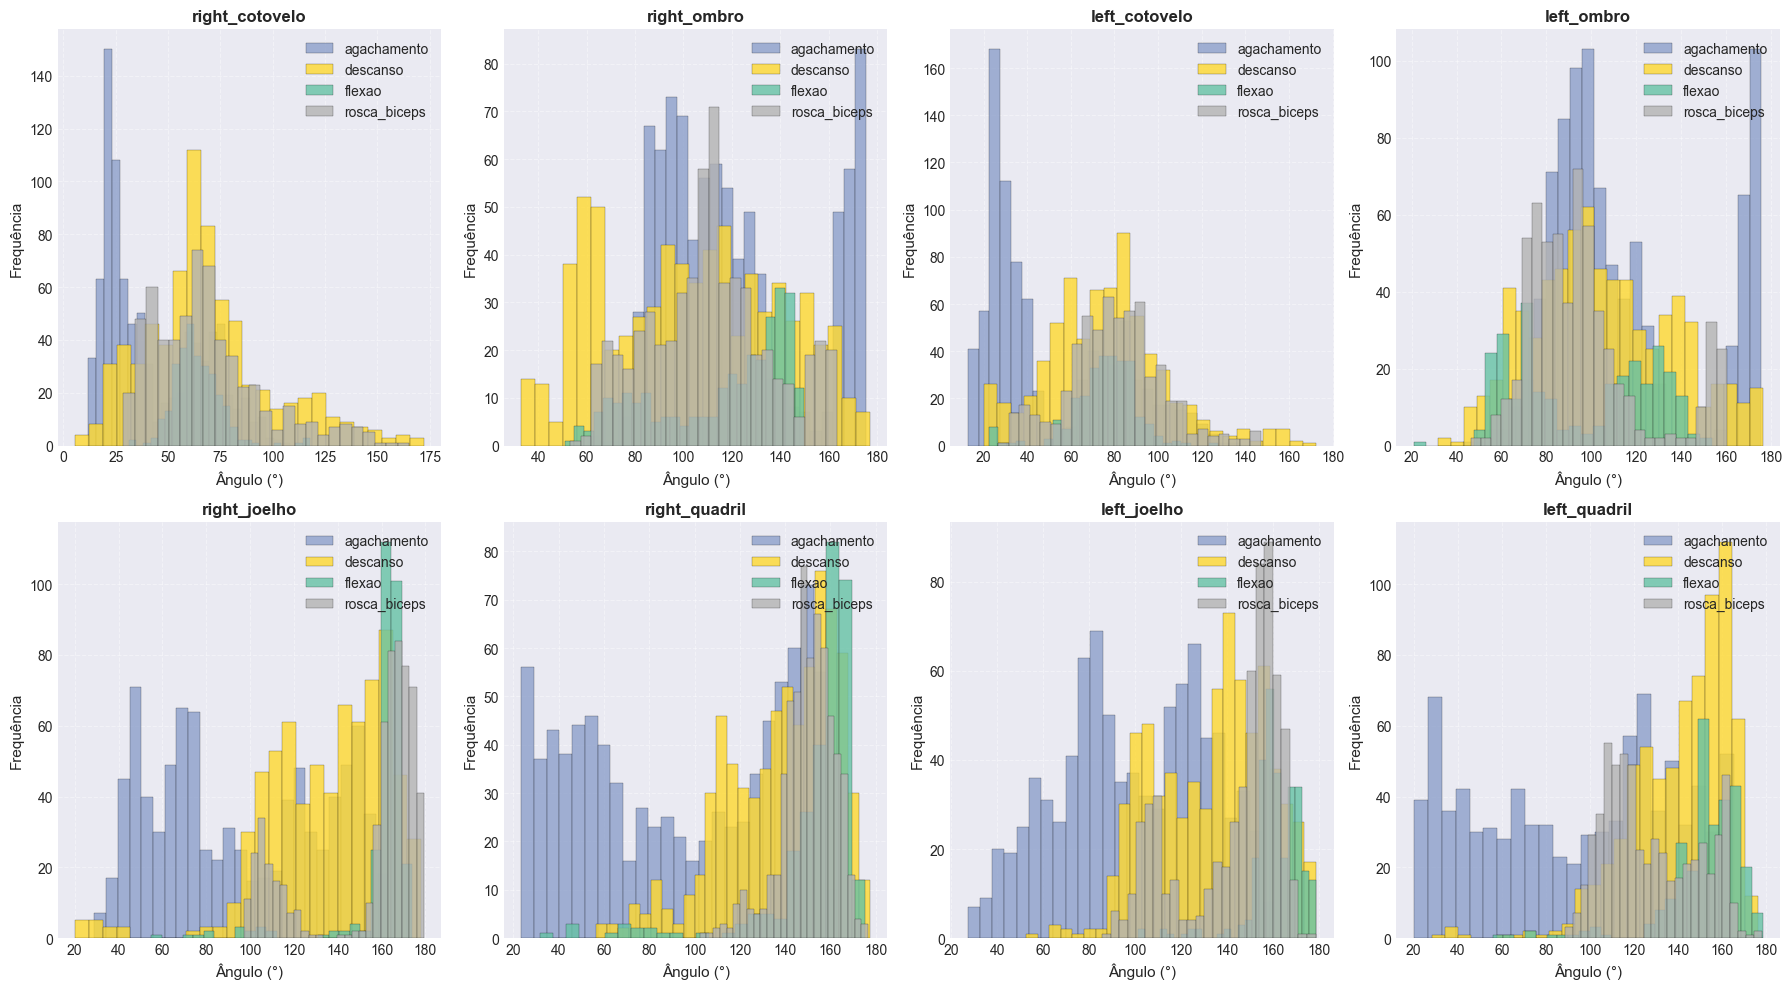

✓ Análise exploratória concluída
  Exercícios visualizados: ['agachamento', 'descanso', 'flexao', 'rosca_biceps']


In [7]:
# Visualizar distribuições com melhor contraste
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

# Cores mais distintas para cada exercício
colors = plt.cm.Set2(np.linspace(0, 1, len(data['exercise'].unique())))
exercise_colors = {ex: colors[i] for i, ex in enumerate(data['exercise'].unique())}

for idx, col in enumerate(angle_columns):
    for exercise in sorted(data['exercise'].unique()):
        subset = data[data['exercise'] == exercise][col]
        axes[idx].hist(subset, alpha=0.8, label=exercise, bins=25, 
                      color=exercise_colors[exercise], edgecolor='black', linewidth=0.2)
    
    axes[idx].set_title(f'{col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Ângulo (°)', fontsize=11)
    axes[idx].set_ylabel('Frequência', fontsize=11)
    axes[idx].legend(fontsize=10, loc='upper right', framealpha=0.95)
    axes[idx].grid(alpha=0.4, linestyle='--')

plt.tight_layout()
# plt.suptitle('Distribuição de Ângulos Articulares por Exercício', fontsize=16, fontweight='bold', y=0.995)
plt.show()

print("✓ Análise exploratória concluída")
print(f"  Exercícios visualizados: {sorted(data['exercise'].unique())}")

In [8]:
data['exercise'].unique()

array(['flexao', 'agachamento', 'descanso', 'rosca_biceps'], dtype=object)

## 3. Temporal Window Feature Engineering

### Estratégia:
- **Janela Deslizante**: 10 frames consecutivos
- **Features Temporais**: Média, std, min, max, range
- **Derivadas**: Velocidade (primeira) e Aceleração (segunda)
- **Tendência**: Slope linear simples
- **Respeito ao Tempo**: Não embaralha dados - usa split temporal

In [9]:
def create_temporal_features_window(df, window_size=10, angle_columns=None):
    """
    Cria features temporais simples usando janelas deslizantes.
    Para cada janela de 10 frames da mesma classe, cria uma linha com 
    os valores dos ângulos para cada frame.
    
    Exemplo: frame_1_right_cotovelo, frame_2_right_cotovelo, ..., frame_10_right_cotovelo
    """
    if angle_columns is None:
        angle_columns = [
            'right_cotovelo', 'right_ombro', 'left_cotovelo', 'left_ombro',
            'right_joelho', 'right_quadril', 'left_joelho', 'left_quadril'
        ]
    
    features_list = []
    labels_list = []
    n_rows = len(df)
    
    # Iterar sobre janelas deslizantes
    for i in range(n_rows - window_size + 1):
        window = df.iloc[i:i + window_size]
        
        # Verificar se há mudança de exercício dentro da janela
        exercises_in_window = window['exercise'].unique()
        if len(exercises_in_window) > 1:
            continue
        
        # Criar features: cada frame como coluna separada
        window_features = {}
        
        for frame_idx in range(window_size):
            frame_data = window.iloc[frame_idx]
            for angle_col in angle_columns:
                col_name = f'frame_{frame_idx + 1}_{angle_col}'
                window_features[col_name] = frame_data[angle_col]
        
        features_list.append(window_features)
        
        # Label do exercício
        label = window.iloc[0]['exercise']  # Todos são iguais, pega qualquer um
        labels_list.append(label)
    
    X = pd.DataFrame(features_list)
    y = pd.Series(labels_list, name='exercise')
    
    print(f"✓ Features criadas: {X.shape[0]} amostras, {X.shape[1]} features")
    print(f"  Colunas: {window_size} frames × {len(angle_columns)} ângulos = {len(angle_columns) * window_size} features")
    print(f"  Classes: {y.value_counts().to_dict()}")
    
    return X, y

# Criar features
print("Criando features com janela de 15 frames...")
X, y = create_temporal_features_window(data, window_size=15, angle_columns=angle_columns)
print(f"\nShape de X: {X.shape}")
print(f"Shape de y: {y.shape}")
print(f"\nPrimeiras colunas: {list(X.columns[:10])}")

Criando features com janela de 15 frames...
✓ Features criadas: 2433 amostras, 120 features
  Colunas: 15 frames × 8 ângulos = 120 features
  Classes: {'agachamento': 873, 'descanso': 700, 'rosca_biceps': 589, 'flexao': 271}

Shape de X: (2433, 120)
Shape de y: (2433,)

Primeiras colunas: ['frame_1_right_cotovelo', 'frame_1_right_ombro', 'frame_1_left_cotovelo', 'frame_1_left_ombro', 'frame_1_right_joelho', 'frame_1_right_quadril', 'frame_1_left_joelho', 'frame_1_left_quadril', 'frame_2_right_cotovelo', 'frame_2_right_ombro']


## 4. Preprocess and Prepare Features

In [10]:
# Codificar labels - 4 classes
label_map = {
    'flexao': 0,
    'agachamento': 1, 
    'descanso': 2,
    'rosca_biceps': 3
}

y_encoded = y.map(label_map)

print("✓ Labels codificados (4 classes):")
for exercise, label in label_map.items():
    count = (y_encoded == label).sum()
    pct = count / len(y_encoded) * 100
    print(f"  {exercise:15} ({label}): {count:6d} amostras ({pct:5.1f}%)")

# Split temporal com distribuição igual nos dados de teste
# Estratégia: pegar últimos 30% de cada classe separadamente para manter temporal
test_size = 0.3

# Separar índices por classe
class_indices = {}
for label in sorted(label_map.values()):
    class_indices[label] = np.where(y_encoded == label)[0]

# Split temporal por classe (últimos 30%)
test_indices_list = []
for label, indices in class_indices.items():
    n_test = int(len(indices) * test_size)
    test_class_idx = indices[-n_test:]  # Últimos frames
    test_indices_list.append(test_class_idx)

test_indices = np.concatenate(test_indices_list)
test_indices = np.sort(test_indices)

# Indices para treino
train_mask = np.ones(len(X), dtype=bool)
train_mask[test_indices] = False
train_indices = np.where(train_mask)[0]

# Dividir dados
X_train = X.iloc[train_indices]
X_test = X.iloc[test_indices]
y_train = y_encoded.iloc[train_indices]
y_test = y_encoded.iloc[test_indices]

print(f"\n✓ Dados divididos (split temporal com distribuição balanceada):")
print(f"  Treino: {len(X_train)} amostras ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Teste: {len(X_test)} amostras ({len(X_test)/len(X)*100:.1f}%)")

print(f"\n  Distribuição treino:")
for label, exercise in [(v, k) for k, v in label_map.items()]:
    count = (y_train == label).sum()
    print(f"    {exercise:15}: {count:6d} ({count/len(y_train)*100:5.1f}%)")

print(f"\n  Distribuição teste:")
for label, exercise in [(v, k) for k, v in label_map.items()]:
    count = (y_test == label).sum()
    print(f"    {exercise:15}: {count:6d} ({count/len(y_test)*100:5.1f}%)")

✓ Labels codificados (4 classes):
  flexao          (0):    271 amostras ( 11.1%)
  agachamento     (1):    873 amostras ( 35.9%)
  descanso        (2):    700 amostras ( 28.8%)
  rosca_biceps    (3):    589 amostras ( 24.2%)

✓ Dados divididos (split temporal com distribuição balanceada):
  Treino: 1705 amostras (70.1%)
  Teste: 728 amostras (29.9%)

  Distribuição treino:
    flexao         :    190 ( 11.1%)
    agachamento    :    612 ( 35.9%)
    descanso       :    490 ( 28.7%)
    rosca_biceps   :    413 ( 24.2%)

  Distribuição teste:
    flexao         :     81 ( 11.1%)
    agachamento    :    261 ( 35.9%)
    descanso       :    210 ( 28.8%)
    rosca_biceps   :    176 ( 24.2%)


In [11]:
# Normalizar features
# IMPORTANTE: Fit apenas em dados de treino para evitar vazamento
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✓ Features normalizadas com StandardScaler")
print(f"  Média de treino: {X_train_scaled.mean():.6f}")
print(f"  Std de treino: {X_train_scaled.std():.6f}")

✓ Features normalizadas com StandardScaler
  Média de treino: 0.000000
  Std de treino: 1.000000


## 5. Train Random Forest Classifier

In [12]:
print("🎯 Treinando Random Forest para 4 exercícios...\n")

# Treinar modelo com ajustes para multiclass
model = RandomForestClassifier(
    n_estimators=300,  # Aumentado para dados multiclass
    max_depth=6,       # Aumentado para 4 classes
    min_samples_split=3,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'  # Importante para multiclass desbalanceado
)

model.fit(X_train_scaled, y_train)
print("✓ Modelo treinado!")

# Cross-validation nos dados de treino
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_accuracy = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='accuracy')
cv_scores_f1 = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='f1_weighted')

print(f"\n📊 Cross-Validation (5-fold):")
print(f"  Accuracy: {cv_scores_accuracy.mean():.4f} (+/- {cv_scores_accuracy.std():.4f})")
print(f"  F1 (weighted): {cv_scores_f1.mean():.4f} (+/- {cv_scores_f1.std():.4f})")

🎯 Treinando Random Forest para 4 exercícios...

✓ Modelo treinado!

📊 Cross-Validation (5-fold):
  Accuracy: 0.9695 (+/- 0.0084)
  F1 (weighted): 0.9696 (+/- 0.0084)


## 6. Evaluate Model Performance

In [13]:
print("📊 Avaliando modelo (Multiclass)...\n")

# Predições
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

y_train_proba = model.predict_proba(X_train_scaled)
y_test_proba = model.predict_proba(X_test_scaled)

# Calcular métricas
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
train_f1 = f1_score(y_train, y_train_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')

# Para AUC em multiclass, usar one-vs-rest
try:
    train_auc = roc_auc_score(y_train, y_train_proba, multi_class='ovr')
    test_auc = roc_auc_score(y_test, y_test_proba, multi_class='ovr')
except:
    train_auc = 0.0
    test_auc = 0.0

# Imprimir resultados
print(f"{'='*60}")
print(f"{'RESULTADOS':<30} {'TREINO':<15} {'TESTE':<15}")
print(f"{'='*60}")
print(f"{'Acurácia':<30} {train_accuracy:<15.4f} {test_accuracy:<15.4f}")
print(f"{'F1-Score (weighted)':<30} {train_f1:<15.4f} {test_f1:<15.4f}")
print(f"{'AUC-ROC':<30} {train_auc:<15.4f} {test_auc:<15.4f}")
print(f"{'='*60}")

# Criar mapeamento inverso
reverse_label_map = {v: k for k, v in label_map.items()}

# Relatório detalhado
print("\n📋 Relatório de Classificação (Teste):")
target_names = [reverse_label_map[i] for i in sorted(label_map.values())]
print(classification_report(y_test, y_test_pred, target_names=target_names))

# Matriz de confusão
print("\n📊 Matriz de Confusão:")
cm = confusion_matrix(y_test, y_test_pred, labels=sorted(label_map.values()))
print(cm)
print(f"\nExercícios: {target_names}")

📊 Avaliando modelo (Multiclass)...

RESULTADOS                     TREINO          TESTE          
Acurácia                       0.9953          0.9121         
F1-Score (weighted)            0.9953          0.9101         
AUC-ROC                        1.0000          0.9934         

📋 Relatório de Classificação (Teste):
              precision    recall  f1-score   support

      flexao       0.80      0.96      0.87        81
 agachamento       0.97      0.98      0.98       261
    descanso       0.92      0.76      0.83       210
rosca_biceps       0.89      0.97      0.92       176

    accuracy                           0.91       728
   macro avg       0.89      0.92      0.90       728
weighted avg       0.92      0.91      0.91       728


📊 Matriz de Confusão:
[[ 78   0   3   0]
 [  0 257   4   0]
 [ 20   9 159  22]
 [  0   0   6 170]]

Exercícios: ['flexao', 'agachamento', 'descanso', 'rosca_biceps']


## 7. Visualize Results and Feature Importance

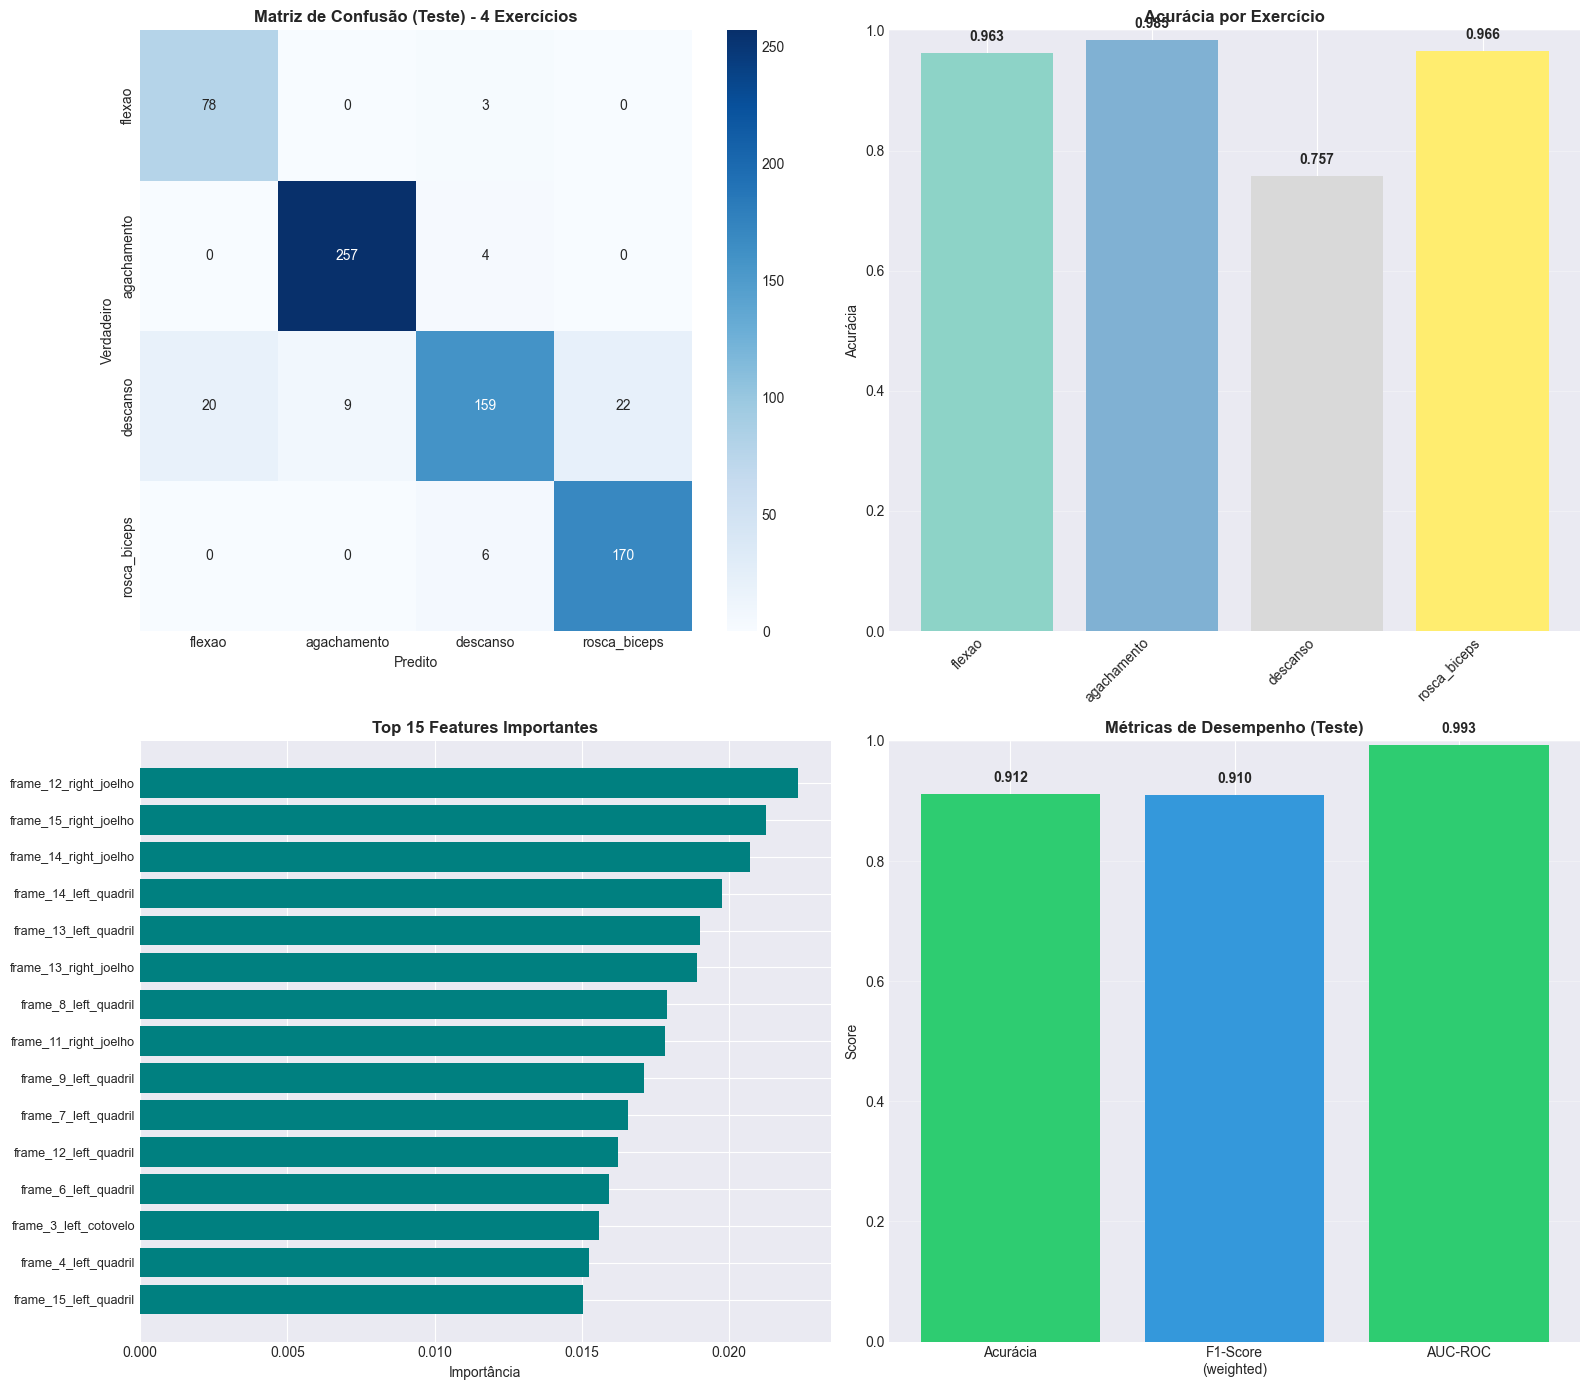

✓ Gráficos salvos!


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# 1. Matriz de Confusão
exercise_names = [reverse_label_map[i] for i in sorted(label_map.values())]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0], cbar=True,
            xticklabels=exercise_names, yticklabels=exercise_names)
axes[0, 0].set_title('Matriz de Confusão (Teste) - 4 Exercícios', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Verdadeiro')
axes[0, 0].set_xlabel('Predito')

# 2. Acurácia por Classe
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)
colors_per_class = plt.cm.Set3(np.linspace(0, 1, len(exercise_names)))
axes[0, 1].bar(exercise_names, per_class_accuracy, color=colors_per_class)
axes[0, 1].set_ylabel('Acurácia')
axes[0, 1].set_title('Acurácia por Exercício', fontsize=12, fontweight='bold')
axes[0, 1].set_ylim([0, 1])
axes[0, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(per_class_accuracy):
    axes[0, 1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')
plt.setp(axes[0, 1].xaxis.get_majorticklabels(), rotation=45, ha='right')

# 3. Top features
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

axes[1, 0].barh(range(len(feature_importance)), feature_importance['importance'].values, color='teal')
axes[1, 0].set_yticks(range(len(feature_importance)))
axes[1, 0].set_yticklabels(feature_importance['feature'].values, fontsize=9)
axes[1, 0].set_xlabel('Importância')
axes[1, 0].set_title('Top 15 Features Importantes', fontsize=12, fontweight='bold')
axes[1, 0].invert_yaxis()

# 4. Métricas gerais
metrics = {
    'Acurácia': test_accuracy,
    'F1-Score\n(weighted)': test_f1,
    'AUC-ROC': test_auc if test_auc > 0 else None
}

if metrics['AUC-ROC'] is None:
    metrics.pop('AUC-ROC')

colors = ['#2ecc71', '#3498db']
bars = axes[1, 1].bar(metrics.keys(), [v for v in metrics.values() if v is not None], color=colors)
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_title('Métricas de Desempenho (Teste)', fontsize=12, fontweight='bold')
axes[1, 1].set_ylim([0, 1])
axes[1, 1].grid(axis='y', alpha=0.3)

for bar, (k, v) in zip(bars, [(k, v) for k, v in metrics.items() if v is not None]):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, v + 0.02, f'{v:.3f}', 
                    ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Gráficos salvos!")

In [15]:
# Análise de erros
print("\n🔍 Análise de Erros\n")

errors = y_test != y_test_pred
error_rate = errors.sum() / len(y_test)

print(f"Total de erros: {errors.sum()} / {len(y_test)} ({error_rate*100:.1f}%)")
print(f"\nDistribuição de erros por exercício:")

for label in sorted(label_map.values()):
    exercise_name = reverse_label_map[label]
    mask = y_test == label
    if mask.sum() > 0:
        exercise_errors = errors[mask].sum()
        exercise_total = mask.sum()
        print(f"  {exercise_name:15}: {exercise_errors:3d} / {exercise_total:3d} erros ({exercise_errors/exercise_total*100:5.1f}%)")

# Feature importance ranking
print("\n⭐ Top 20 Features Mais Importantes:")
top_features = feature_importance.head(20)
for idx, (_, row) in enumerate(top_features.iterrows(), 1):
    print(f"  {idx:2d}. {row['feature']:<40} {row['importance']:.4f}")


🔍 Análise de Erros

Total de erros: 64 / 728 (8.8%)

Distribuição de erros por exercício:
  flexao         :   3 /  81 erros (  3.7%)
  agachamento    :   4 / 261 erros (  1.5%)
  descanso       :  51 / 210 erros ( 24.3%)
  rosca_biceps   :   6 / 176 erros (  3.4%)

⭐ Top 20 Features Mais Importantes:
   1. frame_12_right_joelho                    0.0223
   2. frame_15_right_joelho                    0.0212
   3. frame_14_right_joelho                    0.0207
   4. frame_14_left_quadril                    0.0197
   5. frame_13_left_quadril                    0.0190
   6. frame_13_right_joelho                    0.0189
   7. frame_8_left_quadril                     0.0179
   8. frame_11_right_joelho                    0.0178
   9. frame_9_left_quadril                     0.0171
  10. frame_7_left_quadril                     0.0165
  11. frame_12_left_quadril                    0.0162
  12. frame_6_left_quadril                     0.0159
  13. frame_3_left_cotovelo                    0

## 8. Save Model and Results

In [ ]:
print("💾 Salvando artefatos...\n")

# Salvar modelo na pasta ml_models
model_path = ML_MODELS_DIR / "random_forest_4exercises.pkl"
with open(model_path, 'wb') as f:
    pickle.dump(model, f)
print(f"  ✓ Modelo: {model_path}")

# Salvar scaler
scaler_path = ML_MODELS_DIR / "random_forest_4exercises_scaler.pkl"
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f"  ✓ Scaler: {scaler_path}")

# Salvar label map para referência
label_map_path = ML_MODELS_DIR / "random_forest_4exercises_label_map.pkl"
with open(label_map_path, 'wb') as f:
    pickle.dump(label_map, f)
print(f"  ✓ Label Map: {label_map_path}")


💾 Salvando artefatos...

  ✓ Modelo: ml_models\random_forest_4exercises.pkl
  ✓ Scaler: ml_models\random_forest_4exercises_scaler.pkl
  ✓ Label Map: ml_models\random_forest_4exercises_label_map.pkl
